In [2]:
# Standard library imports
import os
import sys
import io

# Data handling and scientific computing
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.linalg import inv

# PyTorch and related libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
from torch_geometric.nn import GCNConv, NNConv
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

# RDKit for cheminformatics
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, GetPeriodicTable
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdchem
from rdkit.Chem import rdmolops
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import rdMolHash


# NetworkX for network analysis
import networkx as nx

# Matplotlib for plotting and visualization
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Other utilities
from tqdm import tqdm
from PIL import Image

# External datasets
from datasets import load_dataset


import re
import random


from IPython.display import display

sys.path.append('./Code/TestingGround/src/models/')
from all_functions import *



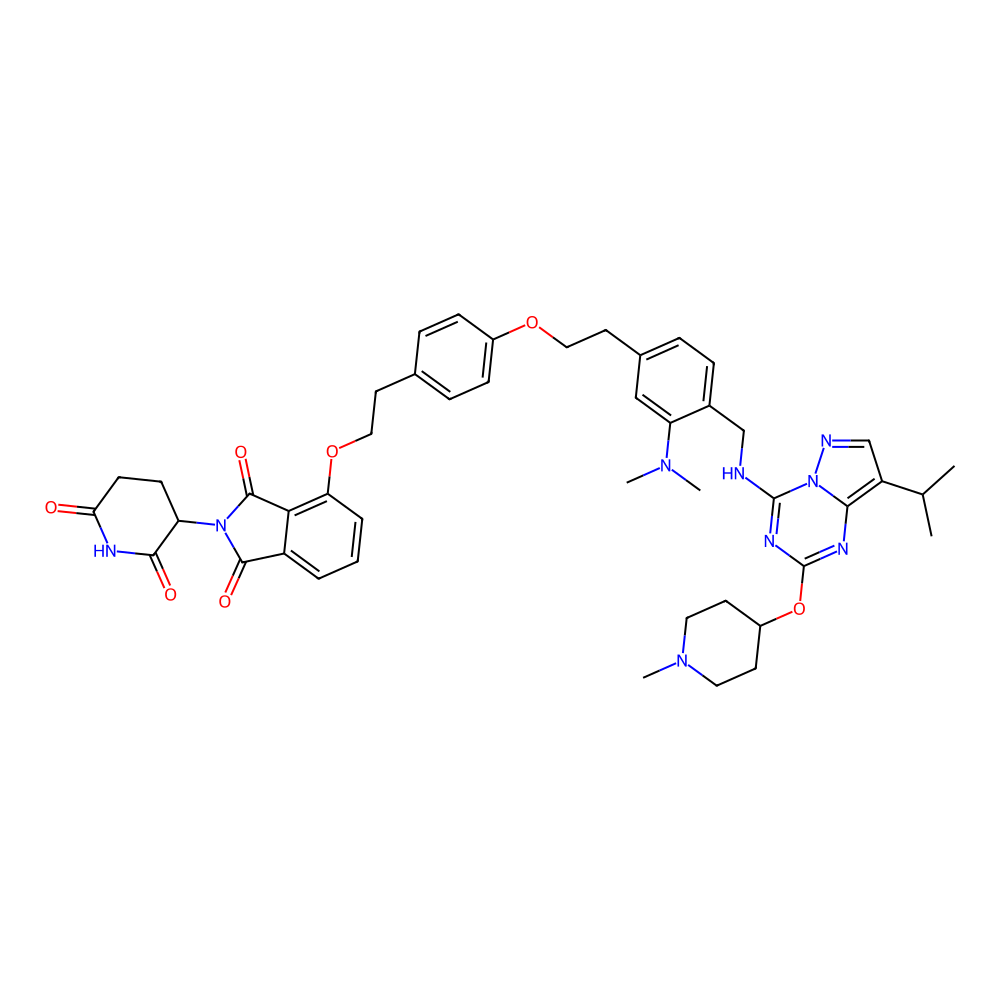

In [7]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def moltosvg(mol, molSize = (1000,1000), kekulize = True, invert_xaxis=False):
    mc = Chem.Mol(mol.ToBinary())
    if kekulize:
        try:
            Chem.Kekulize(mc)
        except:
            mc = Chem.Mol(mol.ToBinary())
    if not mc.GetNumConformers():
        rdDepictor.Compute2DCoords(mc)
    drawer = rdMolDraw2D.MolDraw2DSVG(molSize[0],molSize[1])
    drawer.DrawMolecule(mc)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    return svg.replace('svg:','')

poi_smiles='CC(C)c1cnn2c(NCc3ccc([*:1])cc3N(C)C)nc(OC3CCN(C)CC3)nc12'
linker_smiles='c1cc(OCC[*:1])ccc1CCO[*:2]'
e3_smiles='O=C1CCC(N2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1'
protac_smiles, protac_mol = reassemble_protac(poi_smiles=poi_smiles, linker_smiles=linker_smiles, e3_smiles=e3_smiles)
svg_protac = SVG(moltosvg(protac_mol))
display(svg_protac)


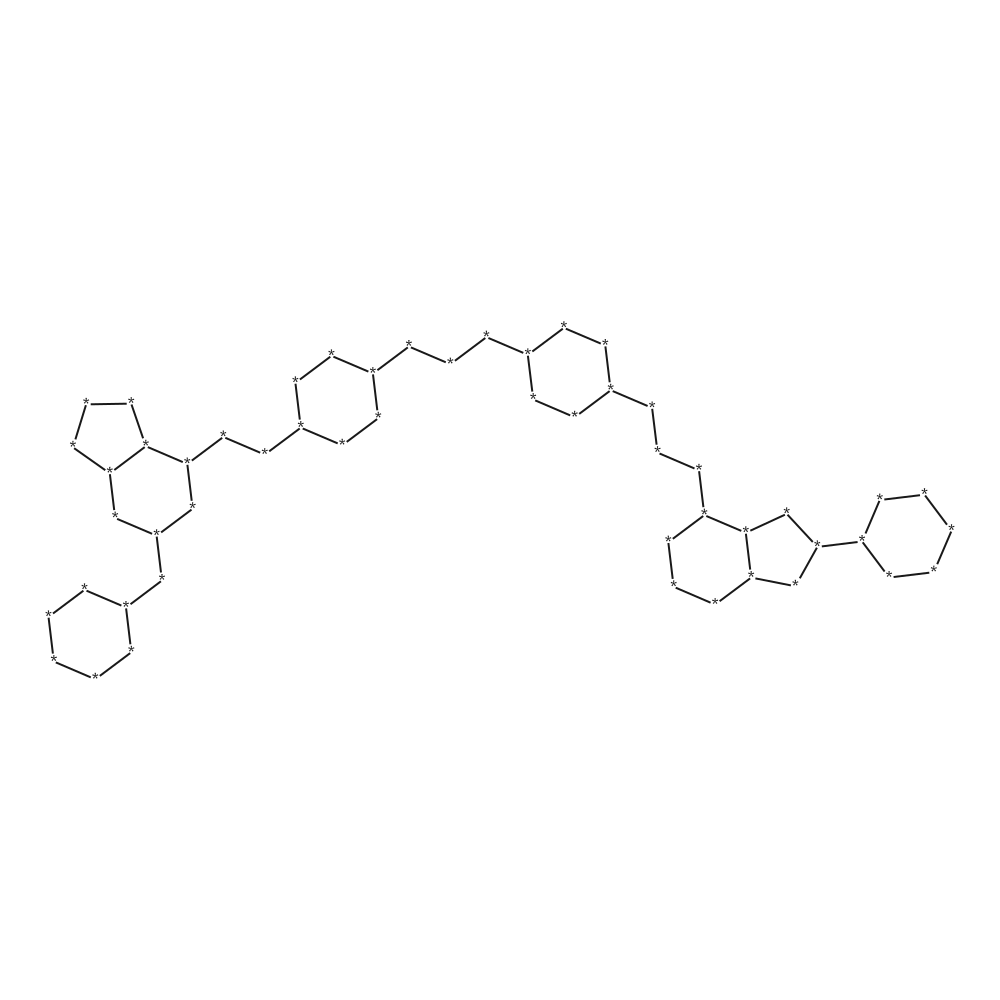

In [8]:
protac_AnonMS_smiles = get_anonymous_murcko(protac_smiles)
protac_AnonMS_mol = Chem.MolFromSmiles(protac_AnonMS_smiles)
svg_protac_AnonMS = SVG(moltosvg(protac_AnonMS_mol))
display(svg_protac_AnonMS)

POI


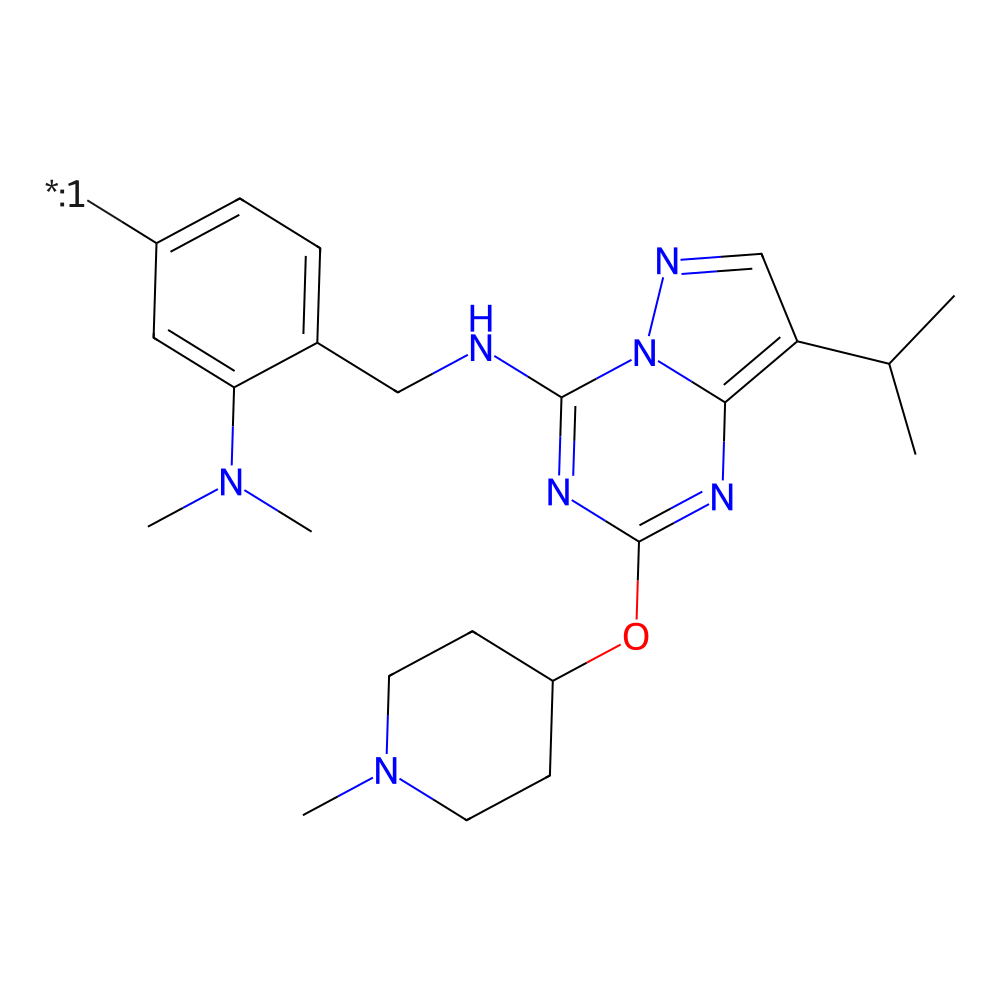

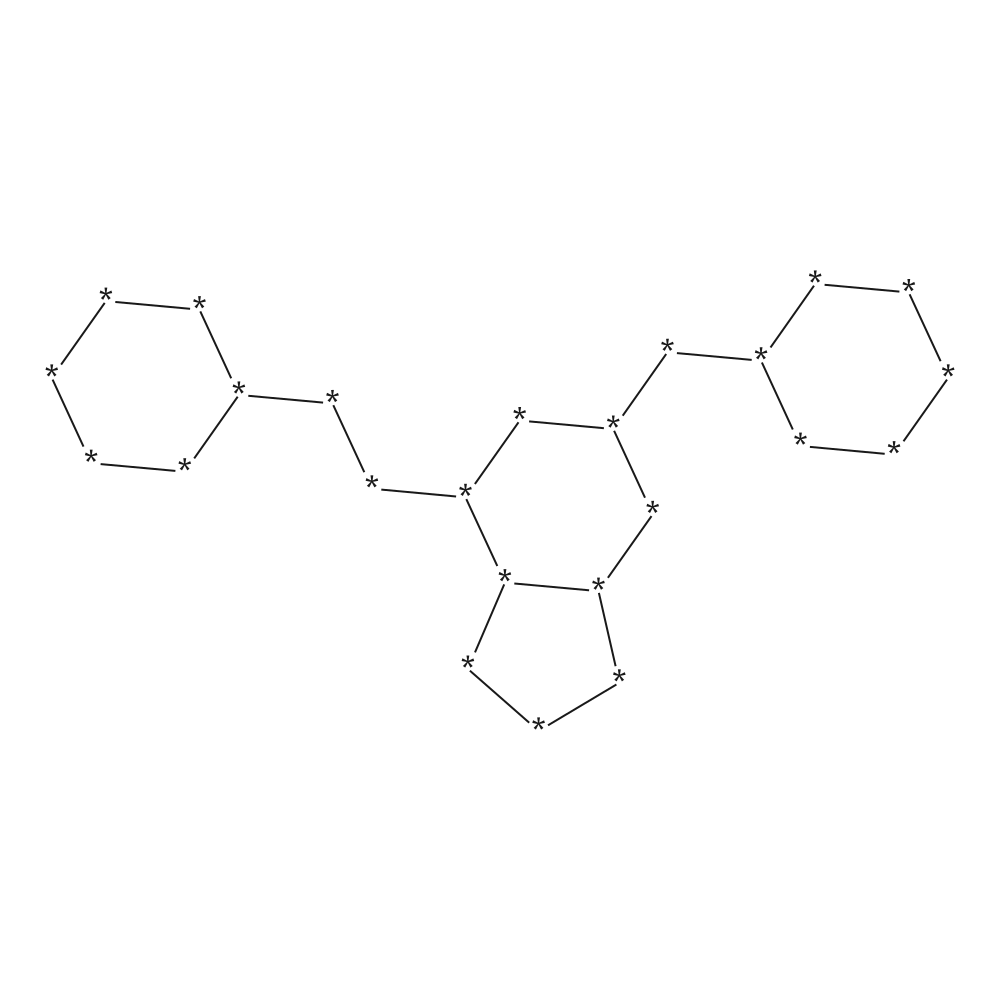

Linker


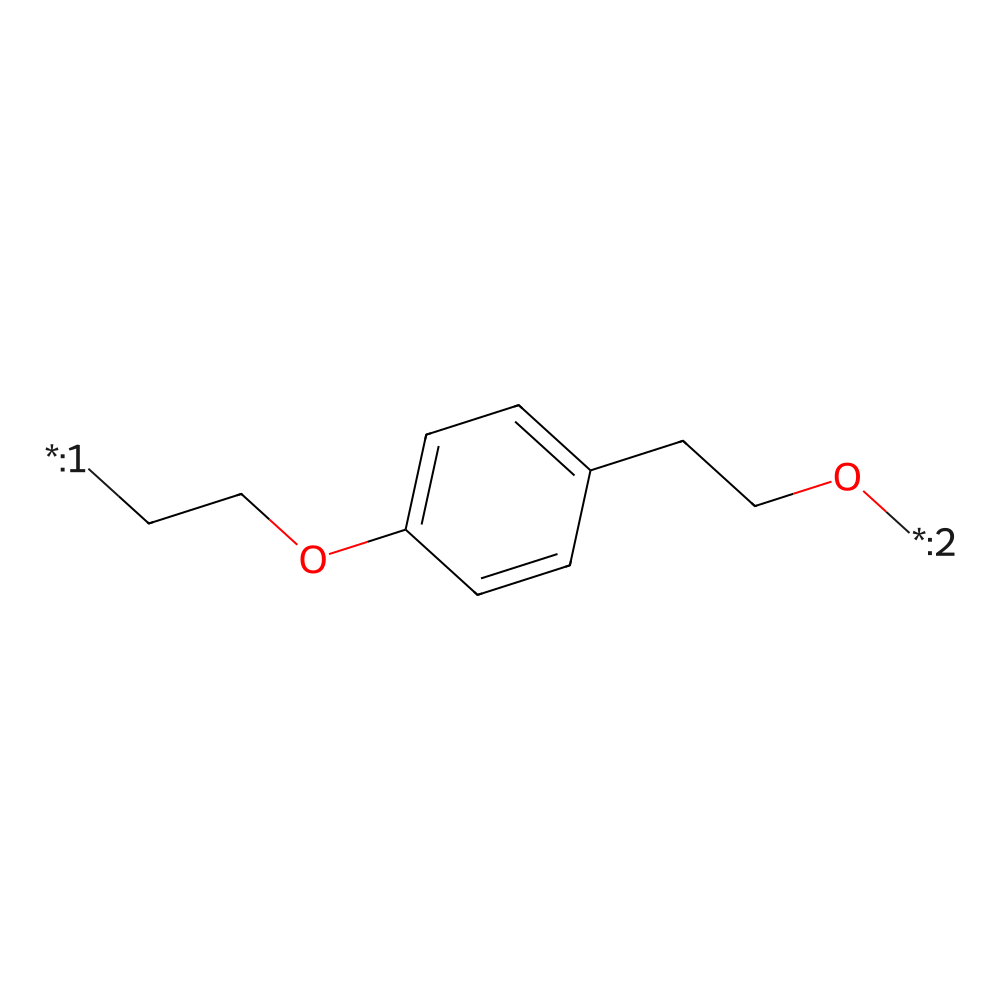

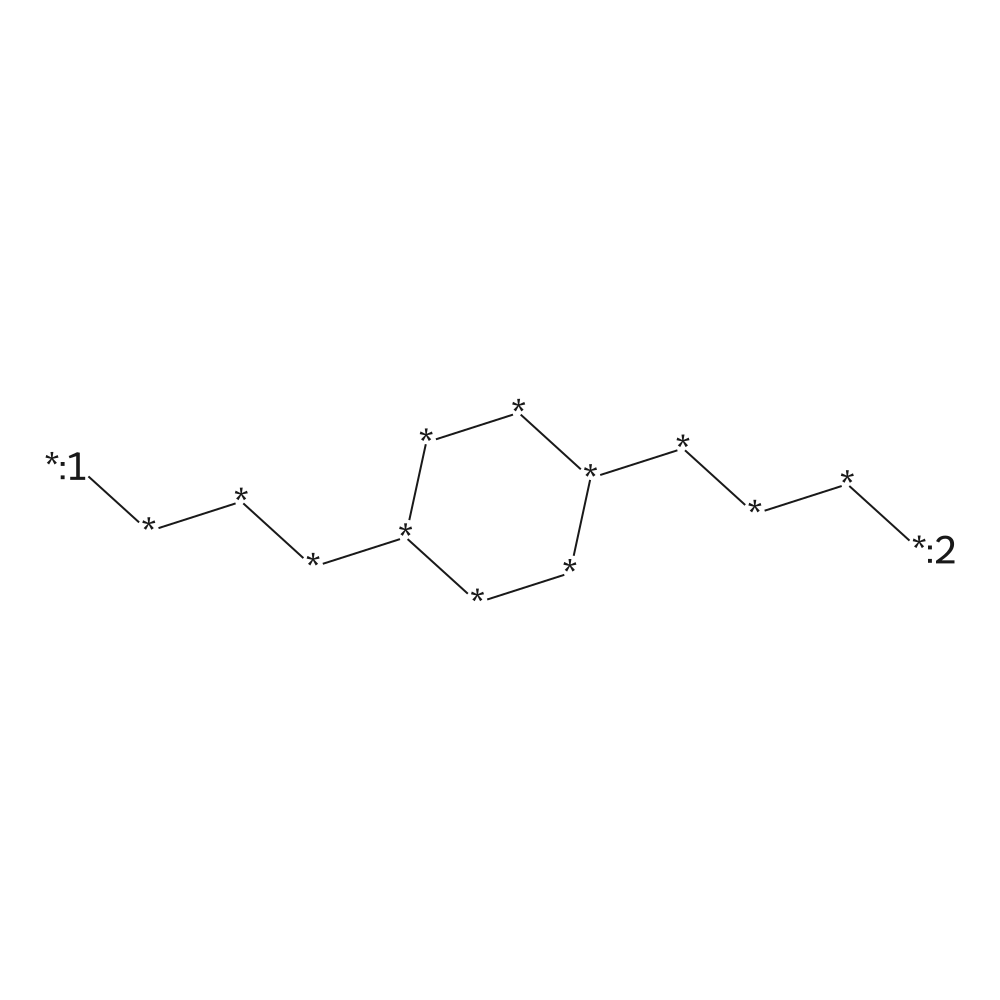

E3


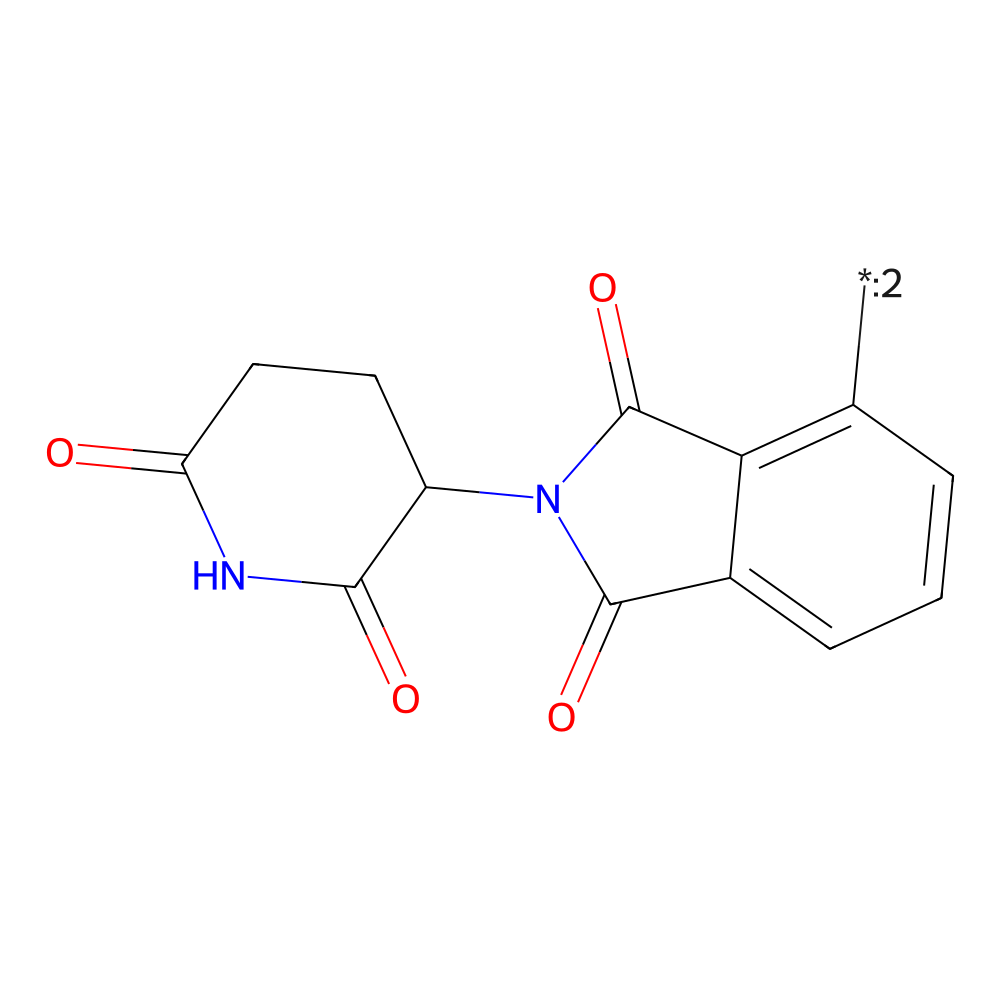

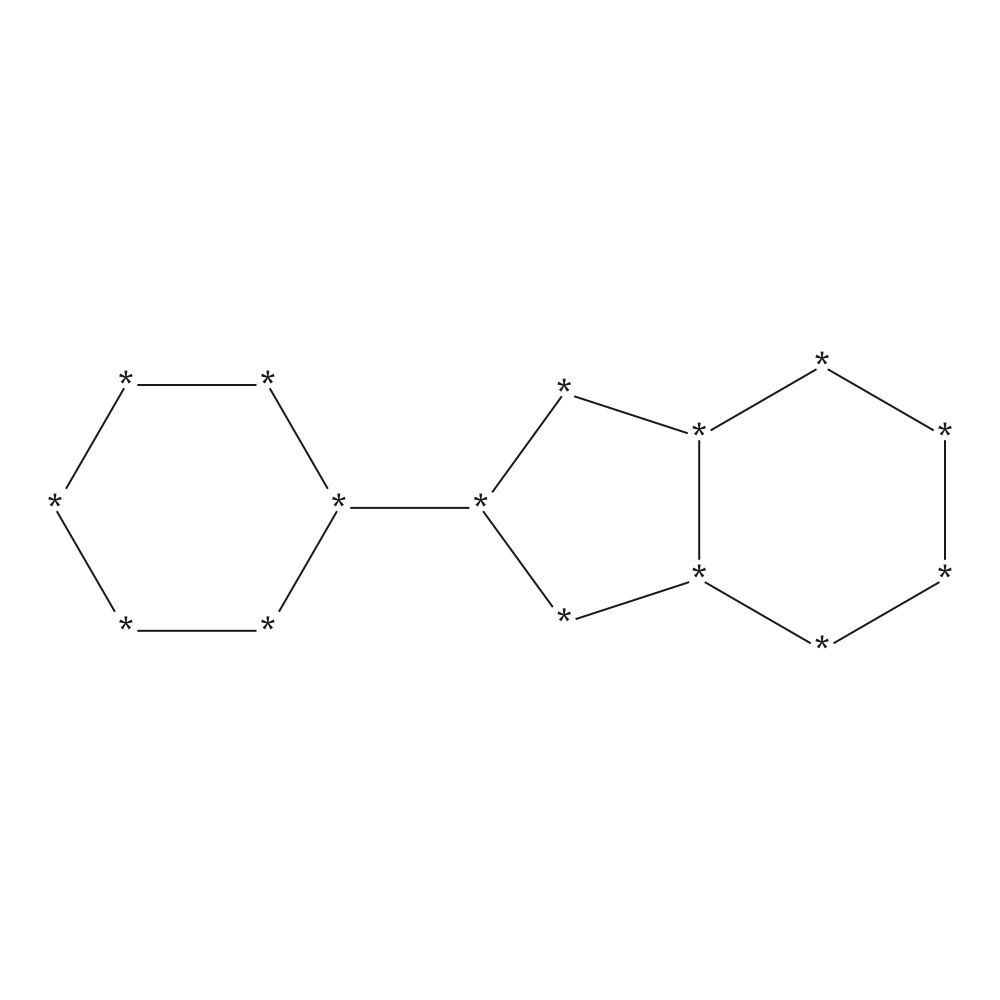

In [13]:
#protac_AnonMS_smiles = get_anonymous_murcko(protac_smiles)
poi_mol = Chem.MolFromSmiles(poi_smiles)
svg_poi = SVG(moltosvg(poi_mol))
linker_mol = Chem.MolFromSmiles(linker_smiles)
svg_linker = SVG(moltosvg(linker_mol))
e3_mol = Chem.MolFromSmiles(e3_smiles)
svg_e3 = SVG(moltosvg(e3_mol))


poi_AnonMS_mol = Chem.MolFromSmiles(get_anonymous_murcko(poi_smiles))
svg_AnonMS_poi = SVG(moltosvg(poi_AnonMS_mol))
linker_AnonMS_mol = Chem.MolFromSmiles(get_anonymous_murcko(linker_smiles))
svg_AnonMS_linker = SVG(moltosvg(linker_AnonMS_mol))
e3_AnonMS_mol = Chem.MolFromSmiles(get_anonymous_murcko(e3_smiles))
svg_AnonMS_e3 = SVG(moltosvg(e3_AnonMS_mol))

print("POI")
display(svg_poi)
display(svg_AnonMS_poi)
print("Linker")
display(svg_linker)
display(svg_AnonMS_linker)
print("E3")
display(svg_e3)
display(svg_AnonMS_e3)


['black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'black']
[13]


(-16.828606499259944, 20.95505583214816, -9.639179218803658, 6.812441942461238)

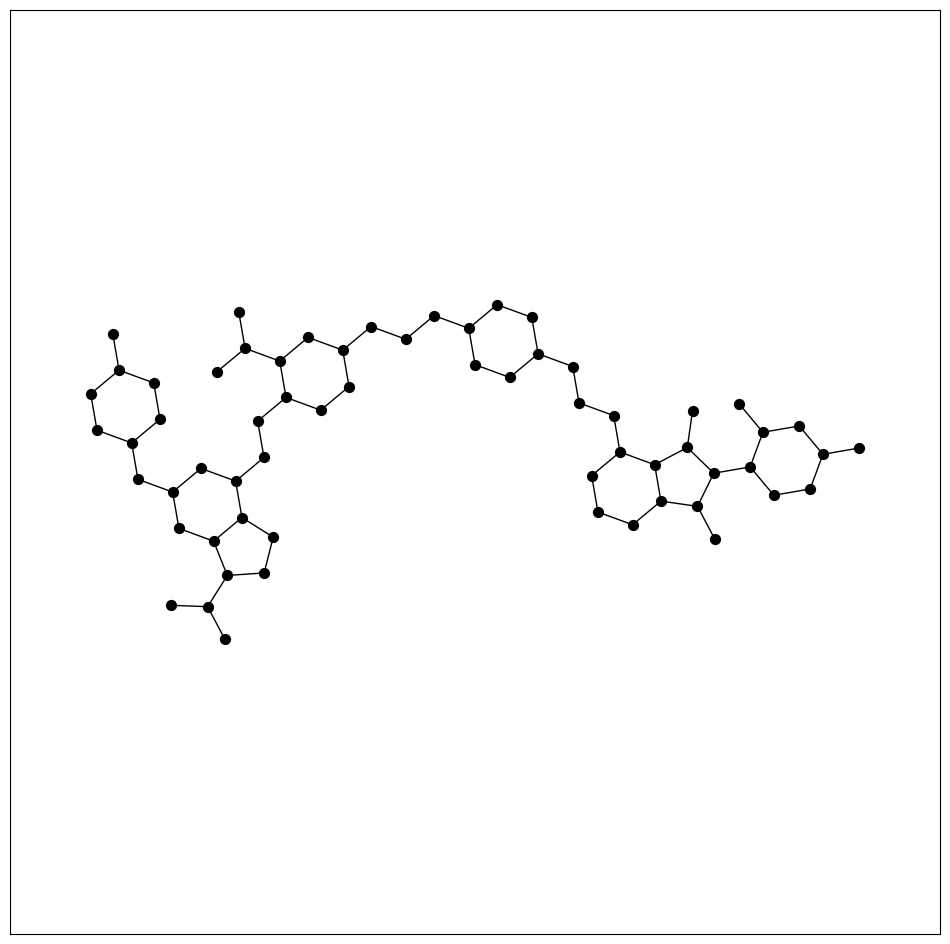

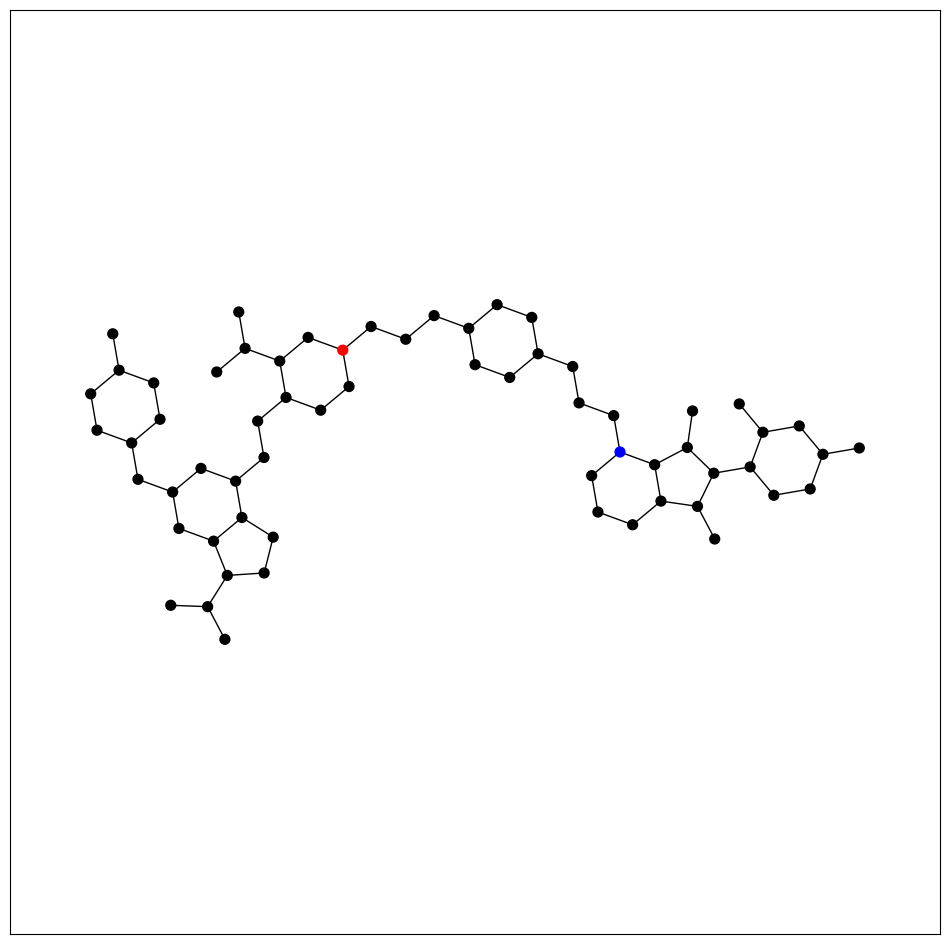

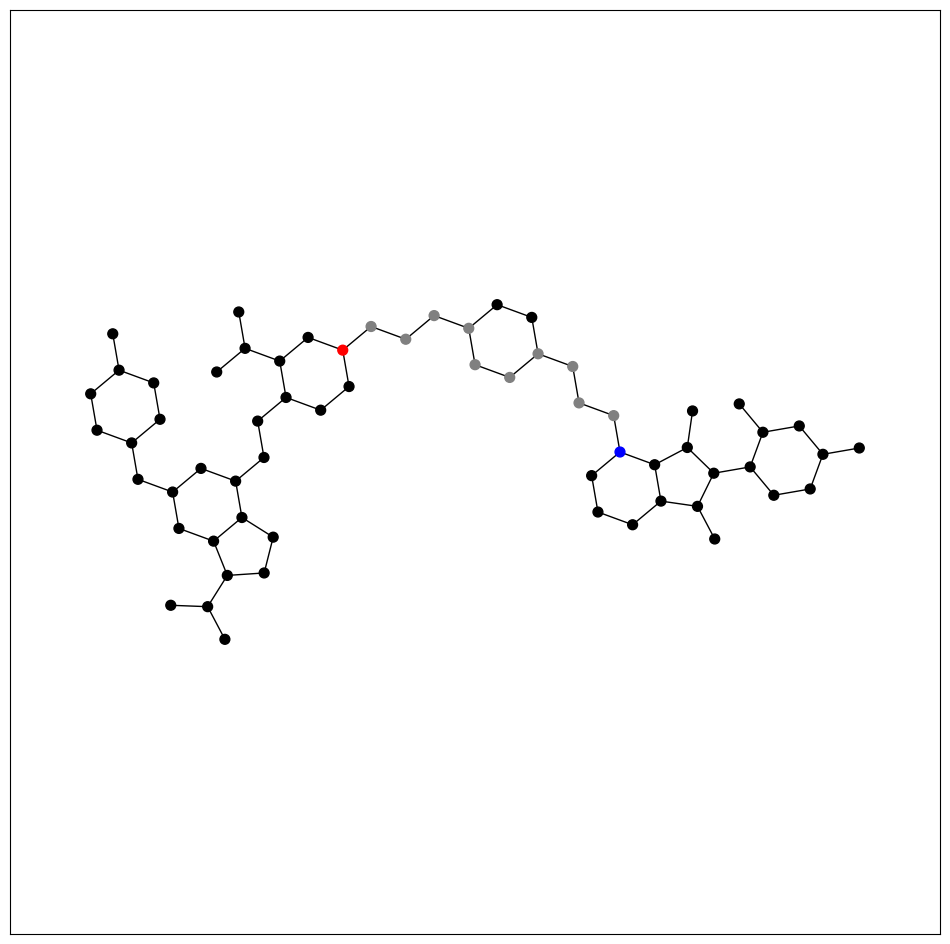

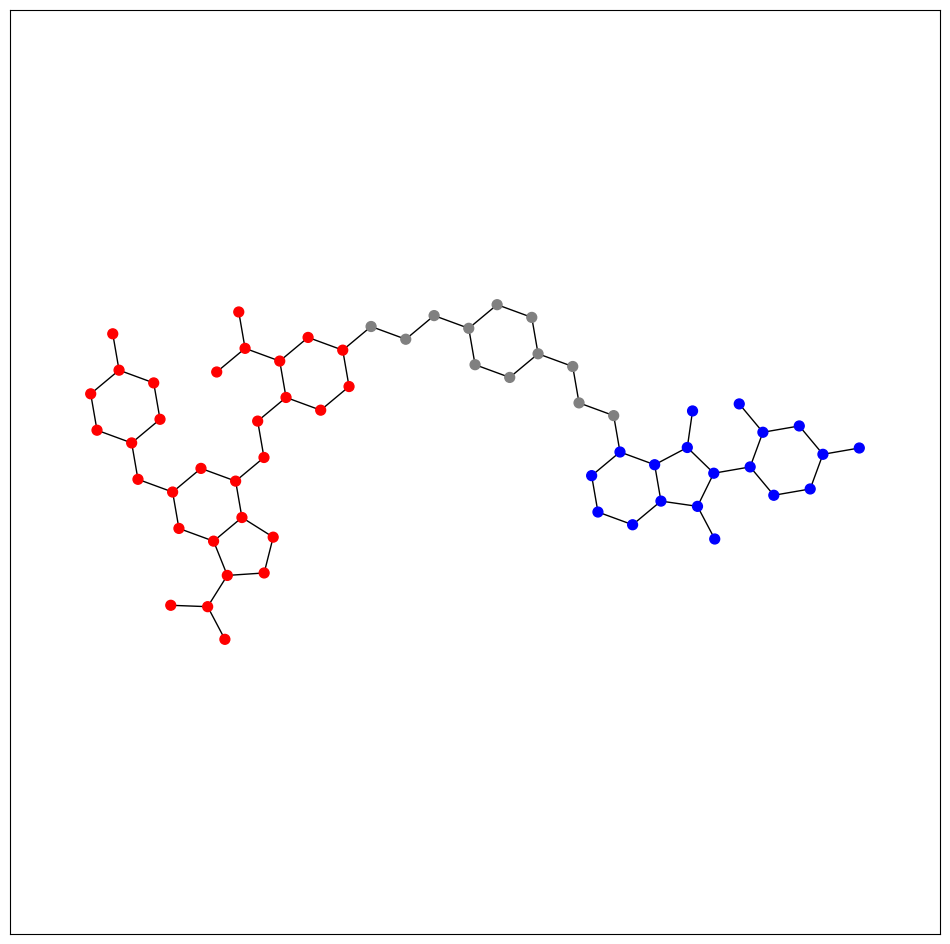

In [12]:
plt.figure(figsize=(12,12))
G, pos = make_graph_with_pos(protac_smiles)


nx.draw_networkx(G, pos=pos,  node_color='black', with_labels=False, node_size = 50)
plt.axis('equal')

node_substructure_label_np = one_hot_encode_substructure_labels(protac_smiles, poi_smiles, e3_smiles)
substructure_smiles = f'{poi_smiles}.{linker_smiles}.{e3_smiles}'
boundary_POI_node_index, boundary_E3_node_index = boundary_ligand_nodes(protac_smiles, substructure_smiles)





plt.figure(figsize=(12,12))
G, pos = make_graph_with_pos(protac_smiles)

color = ['black']*len(G)
print(color)
print(boundary_POI_node_index)
color[boundary_POI_node_index[0]] = 'red'
color[boundary_E3_node_index[0]] = 'blue'


nx.draw_networkx(G, pos=pos,  node_color=color, with_labels=False, node_size = 50)
plt.axis('equal')

plt.figure(figsize=(12,12))
G, pos = make_graph_with_pos(protac_smiles)

color = ['black']*len(G)
#print(color)
#print(boundary_POI_node_index)
path_nodes = nx.shortest_path(G, source=boundary_POI_node_index[0], target=boundary_E3_node_index[0])
intermediate_path_nodes = path_nodes[1:-1]
for node_idx in intermediate_path_nodes:
    color[node_idx] = 'gray'
color[boundary_POI_node_index[0]] = 'red'
color[boundary_E3_node_index[0]] = 'blue'

nx.draw_networkx(G, pos=pos,  node_color=color, with_labels=False, node_size = 50)
plt.axis('equal')
substructure_onehot = one_hot_encode_substructure_labels(protac_smiles, poi_smiles, e3_smiles)
substructclasses_list = np.argmax(substructure_onehot, axis=1).tolist()

substructclass_color_encoding = ['red','gray','blue']
for i, substructclass in enumerate(substructclasses_list):
    substructclasses_list[i] = substructclass_color_encoding[substructclasses_list[i]]

color = substructclasses_list

plt.figure(figsize=(12,12))
G, pos = make_graph_with_pos(protac_smiles)

nx.draw_networkx(G, pos=pos,  node_color=color, with_labels=False, node_size = 50)
plt.axis('equal')
